In [ ]:
import pandas as pd
import numpy as np

df = pd.DataFrame({
    'seller': ['Alice', 'Bob', 'Charlie', 'Bob', 'Alice'],
    'sales': [500, 300, 700, 200, 150],
    'region': ['North', 'South', 'East', 'West', 'North'],
    'month': ['January', 'February', 'March', 'April', 'May']
})

In [ ]:
df['tax'] = df.apply(lambda x: x['sales'] * (1-0.8), axis=1)

#or

df['tax'] = df['sales'] * (1-0.8)
df['label'] = df.apply(lambda x: 'high' if x['sales'] > 400 else 'low', axis=1)

In [ ]:
#np.where() ile de aynı işlemi yapabiliriz, np.where() üç parametre alır, ilk parametre koşul, ikinci parametre koşul doğruysa döndürülecek değer, üçüncü parametre koşul yanlışsa döndürülecek değer
#but with numpy
df['numpy_lable'] = np.where(df['sales'] > 400, 'high', 'low')
df

In [ ]:
#np.select() ile birden fazla koşul ve birden fazla label oluşturabiliriz
conditions = [
    df['sales'] == 700,
    df['sales'] == 500,
    df['sales'] == 300,
    df['sales'] == 200
]

labels = ['very high', 'high', 'medium', 'low']


df['with_select'] = np.select(conditions, labels, default='uknown')
df

In [53]:
# np.log(x) kullanimiyoruz
x=0
# kullanıcı satın alma sayısı
# günlük hata sayısı
# günlük sipariş sayısı
# bir kelimenin geçme sayısı    <=== bu tur verilerde sifirlar cok yaygindir
#dolayisiyla np.log(0) tanimsizdir ==> -inf uretir
np.log(0) # <== -inf


C:\Users\nuri\AppData\Local\Temp\ipykernel_18180\2477736380.py:8: RuntimeWarning: divide by zero encountered in log
  np.log(0) # <== -inf


np.float64(-inf)

In [58]:
np.log1p(0)  # = log(1) 0
np.log(1)

np.float64(0.0)

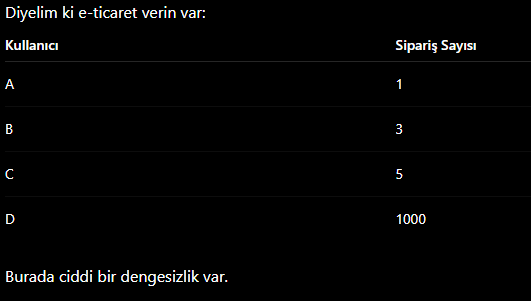
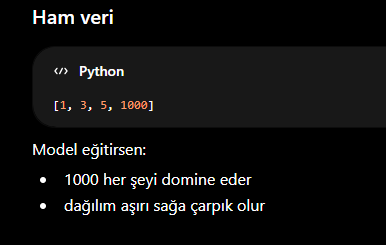

In [ ]:
orders = [1, 3, 5, 1000] # model egitirken 1000 domine eder asiri saga carpar
np.log1p(orders) # ===>  array([0.69314718, 1.38629436, 1.79175947, 6.90875478]) 1000-in etkisi kontrollu

array([0.69314718, 1.38629436, 1.79175947, 6.90875478])

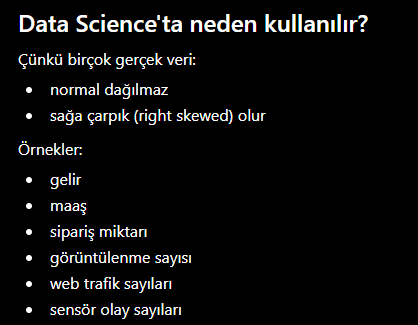
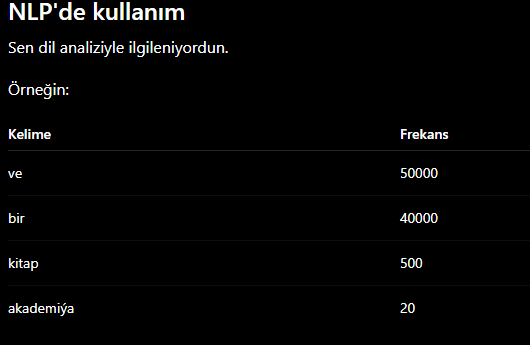

> Amaç Veriyi daha normal dağılıma yaklaştırmak.

---
*** 
np.log1p(x) = log(1+x)
Sıfır değerlerle güvenli çalışır.
Büyük değerlerin etkisini azaltır.
Sağa çarpık dağılımları normalize etmeye yardımcı olur.
NLP, finans, e-ticaret, zaman serileri, anomali tespiti ve makine öğrenmesinde çok yaygın kullanılır.
Pratikte np.log(x) yerine çoğu zaman np.log1p(x) tercih edilir çünkü gerçek verilerde sıfırlar kaçınılmazdır.
***
---

In [59]:
df['sales_log'] = np.log1p(df['sales'])
df
# ?? np.log1p

,seller,sales,region,month,tax,label,numpy_lable,with_select,sales_log
0,Alice,500,North,January,100.0,high,high,high,6.216606
1,Bob,300,South,February,60.0,low,low,medium,5.707110
2,Charlie,700,East,March,140.0,high,high,very high,6.552508
3,Bob,200,West,April,40.0,low,low,low,5.303305
4,Alice,150,North,May,30.0,low,low,uknown,5.017280


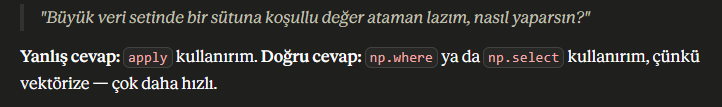

In [ ]:
arr = np.array([[1,2,3], [1,2,3]])
arr.shape #2 rows, 3 columns
arr.reshape(3,2) #<== 3 rows, 2 columns

In [ ]:
arr.flatten() 

In [63]:
df_task = pd.DataFrame({
    'customer_id': [1,2,3,4,5,6],
    'age': [23,45,65,23,34,48],
    'income': [10000, 12000, 8000, 2500, 4000, 5000],
    'ordered_pcs': [3, 5,6,4,2,2000]
})
df_task.describe().T

,count,mean,std,min,25%,50%,75%,max
customer_id,6.0,3.500000,1.870829,1.0,2.25,3.5,4.75,6.0
age,6.0,39.666667,16.293148,23.0,25.75,39.5,47.25,65.0
income,6.0,6916.666667,3693.462693,2500.0,4250.00,6500.0,9500.00,12000.0
ordered_pcs,6.0,336.666667,814.864815,2.0,3.25,4.5,5.75,2000.0


In [64]:
df_task['labling_by_income'] = np.where(df_task['income'] > 8000, "High", "Low")
df_task

,customer_id,age,income,ordered_pcs,labling_by_income
0,1,23,10000,3,High
1,2,45,12000,5,High
2,3,65,8000,6,Low
3,4,23,2500,4,Low
4,5,34,4000,2,Low
5,6,48,5000,2000,Low


In [65]:
condition = [
    df_task['age'] < 25,
    df_task['age'] < 40,
    df_task['age'] < 60,
]

choices = ['gen-z', 'millenia', 'gen-x']

df_task['lable_by_age'] = np.select(condition, choices, default='unknown')
df_task

,customer_id,age,income,ordered_pcs,labling_by_income,lable_by_age
0,1,23,10000,3,High,gen-z
1,2,45,12000,5,High,gen-x
2,3,65,8000,6,Low,unknown
3,4,23,2500,4,Low,gen-z
4,5,34,4000,2,Low,millenia
5,6,48,5000,2000,Low,gen-x


In [67]:
df_task['order_pcs_log'] = np.log1p(df_task['ordered_pcs'])
df_task

,customer_id,age,income,ordered_pcs,labling_by_income,lable_by_age,order_pcs_log
0,1,23,10000,3,High,gen-z,1.386294
1,2,45,12000,5,High,gen-x,1.791759
2,3,65,8000,6,Low,unknown,1.945910
3,4,23,2500,4,Low,gen-z,1.609438
4,5,34,4000,2,Low,millenia,1.098612
5,6,48,5000,2000,Low,gen-x,7.601402
